In [1]:
import scipy 
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import os

from dpd_baselines.utils.data_loader import BlackBoxData80Loader
from dpd_baselines.models.Hammershtain_model import Hammershtain

dpd_baseline_path = Path(r'D:\github_projects\dpd-baselines')
os.chdir(dpd_baseline_path)
signal_path = Path(r'data\BlackBoxData_80.mat')

fs = 1.2288e6
data = BlackBoxData80Loader(signal_path, seq_len=2**10)
data.normalize()
BL_coeff = data.apply_bl()
x_t, y_t, _ = data.get_signals()

model = Hammershtain([0], [3], 2)

In [2]:
for name, p in model.named_parameters():
    print(name, p.shape, p.dtype, "requires_grad=", p.requires_grad)

fir.h torch.Size([2]) torch.complex64 requires_grad= True
poly_bank.0.p.coeff torch.Size([3]) torch.float32 requires_grad= True


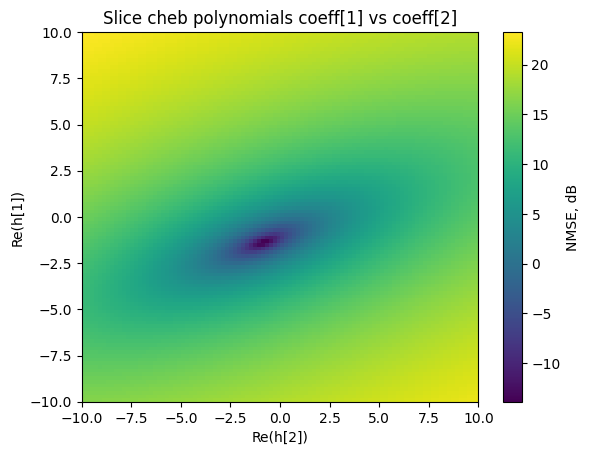

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.as_tensor(x_t, dtype=torch.complex64, device=device)
y = torch.as_tensor(y_t, dtype=torch.complex64, device=device)

model = model.to(device).eval()

@torch.no_grad()
def nmse(y_hat, y_true, ref, eps=1e-12):
    err = (y_hat - y_true).abs().pow(2).mean()
    ref = ref.abs().pow(2).mean()
    return 10*torch.log10(err / (ref + eps))


h = model.poly_bank[0].p.coeff
h0 = h.detach().clone()

grid = np.linspace(-10, 10, 100)
Z = np.zeros((len(grid), len(grid)))

with torch.no_grad():
    for i, a in enumerate(grid):
        for j, b in enumerate(grid):
            h.copy_(h0)
            h[0] = torch.tensor(a, dtype=h.dtype, device=device)
            h[2] = torch.tensor(b, dtype=h.dtype, device=device)
            Z[i, j] = nmse(model(x), y, x).item()



plt.imshow(Z, origin="lower",
           extent=[grid[0], grid[-1], grid[0], grid[-1]],
           aspect="auto")
plt.colorbar(label="NMSE, dB")
plt.xlabel("Re(h[2])")
plt.ylabel("Re(h[1])")
plt.title("Slice cheb polynomials coeff[1] vs coeff[2]")
plt.show()